# Neural ODE / Continious Normalizing on MNIST-Dataset

In [3]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchdiffeq import odeint_adjoint
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Device:", torch.cuda.get_device_name(0))
    print(torch.cuda.device_count())  # sollte 2 ausgeben
    print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

2026-05-05 21:49:22.175162: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778017762.372084      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778017762.427423      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778017762.870409      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778017762.870453      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778017762.870456      57 computation_placer.cc:177] computation placer alr

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Device: Tesla P100-PCIE-16GB
1
['Tesla P100-PCIE-16GB']
Compute capability: (6, 0)
Supported archs: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


## 1. Loading MNIST-Dataset

In [3]:
# download test and trainset of mnist via pytorchvision
# define a transformation from PIL to tensor with normalized pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# download mnist dataset
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# get images
images = train_set.data
labels = train_set.targets

print()
print(train_set)
print()
print("shape images: ", images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.68MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

shape images:  torch.Size([60000, 28, 28])


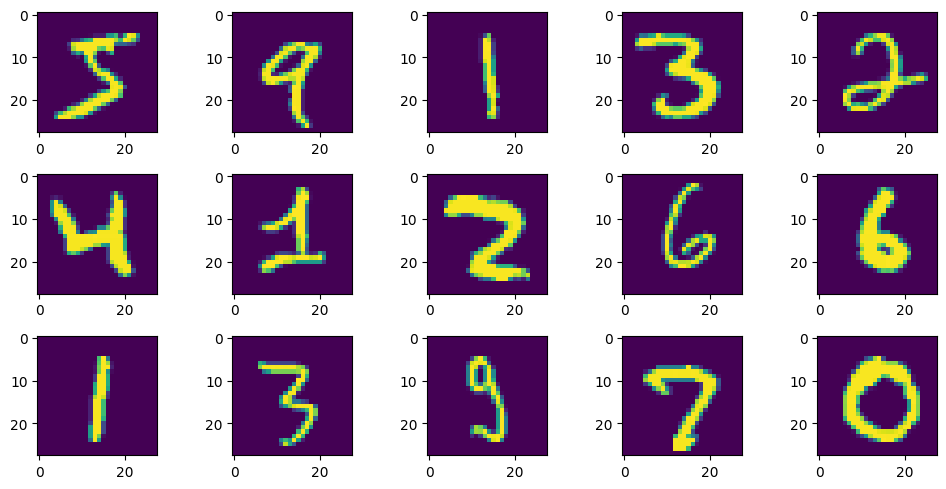

In [4]:
# plot example images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))
ax = ax.flatten()
for i in range(0, 60, 4):
    ax[int(i/4)].imshow(images[i])
fig.tight_layout()

In [5]:
# reduce multidimensional data distribution onto 2D plain with UMAP
reducer = UMAP(n_neighbors=5, n_components=2, min_dist=0.4, metric="euclidean")

# fit reducer onto data
X = images.reshape(len(train_set), -1)
reducer.fit(X)

# make embedding
embedding_train_set = reducer.transform(X).T

(2, 60000)


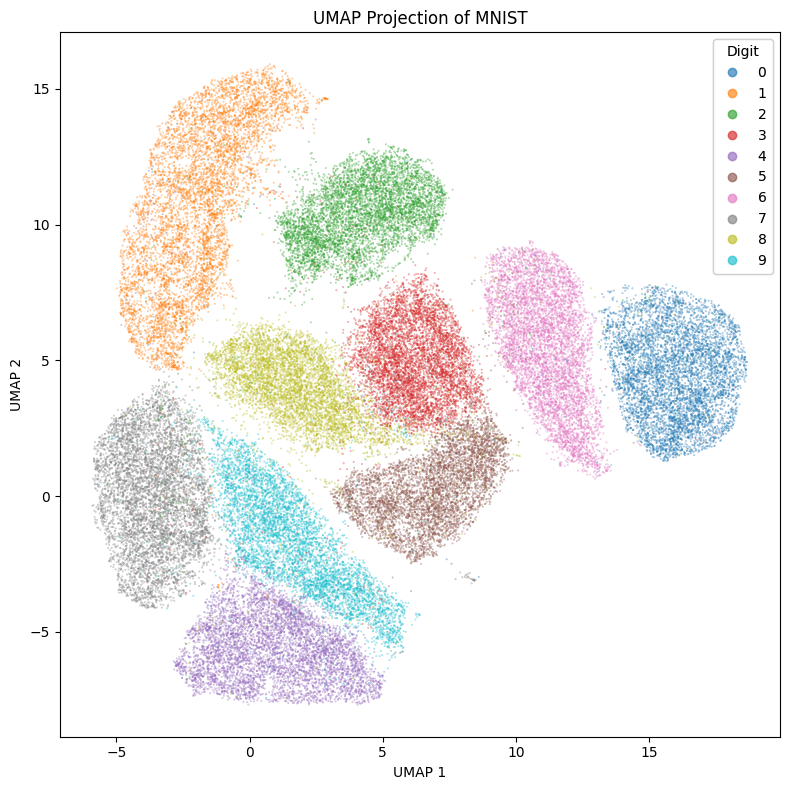

In [6]:
# plot embedding
print(embedding_train_set.shape)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(embedding_train_set[0], embedding_train_set[1], s=0.1, alpha=0.6, c=labels, cmap="tab10")
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="best")
ax.add_artist(legend)

ax.set_title("UMAP Projection of MNIST")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 2. Define Model

In [7]:
# injection of time t into CNN
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -np.log(10000) * torch.arange(half, device=t.device) / half
    )
    args = t[:, None] * freqs[None, :]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeEmbedding(nn.Module):
    def __init__(self, sin_dim=128, t_dim=256):
        super().__init__()
        self.sin_dim = sin_dim
        self.mlp = nn.Sequential(
            nn.Linear(sin_dim, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

    def forward(self, t):
        h = sinusoidal_embedding(t, self.sin_dim)
        return self.mlp(h)   

In [8]:
# monte carlo estimate of trace for fewer computational complexity
def hutchinson_trace_estimate(dz_dt, z, training=False, eps=None, n_samples=1):
        trace = torch.zeros(z.shape[0], device=z.device)
        for i in range(n_samples):
            v = torch.ones_like(z)
            if eps is None:
                v[torch.rand_like(z) < 0.5] = -1
            else:
                v[eps < 0.5] = -1            
            vjp = torch.autograd.grad(dz_dt, z, grad_outputs=v, create_graph=training)[0]
            trace += (vjp * v).flatten(1).sum(1)
        return trace / n_samples

In [9]:
class ResBlock(nn.Module):
    def __init__(self, input_channels, output_channels, t_dim, kernel_size, stride=1, padding=1):
        super().__init__()

        # CNN layers
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.norm1 = nn.GroupNorm(1, output_channels)
        self.activation = nn.SiLU()
        self.film = nn.Linear(t_dim, 2*output_channels)
        self.skip  = nn.Conv2d(input_channels, output_channels, 1) if input_channels != output_channels else nn.Identity()

    def forward(self, t_emb, z):
        residual = self.skip(z)
        
        # Conv layer
        z = self.conv1(z)
        z = self.norm1(z)

        # FiLM injection of time
        beta, gamma = self.film(t_emb).chunk(2, -1)
        z = (1+gamma[:, :, None, None]) * z + beta[:, :, None, None]
        
        # activation
        z = self.activation(z)
        return residual + z


class Sampling(nn.Module):
    def __init__(self,  channels, kernelsize_sampling=None, kernelsize_conv=None, upscale=None, upsampling=False):
        super().__init__()
        if not upsampling:
            self.sampling = nn.AvgPool2d(kernel_size=kernelsize_sampling)
            self.conv = lambda x: x
        else:
            self.sampling = nn.Upsample(scale_factor=upscale)
            self.conv = nn.Conv2d(channels, channels, kernel_size=kernelsize_conv, padding=1)

    def forward(self, z):
        z = self.sampling(z)
        return self.conv(z)


class CNF(nn.Module):
    def __init__(self, channel, nb_filters, kernelsize, sin_dim=64, t_dim=128):
        super().__init__()
        # epsilon for hutchinson estimator (here to get less stochasity, because addaptive solver can have problems)
        self.eps = None

        # store dimension of FiLM embedding dimension
        self.t_dim = t_dim
        self.sin_dim = sin_dim
        self.time_embedding = TimeEmbedding(sin_dim=self.sin_dim, t_dim=self.t_dim)

        # ResNet layers
        self.resblock1 = ResBlock(channel, nb_filters, self.t_dim, kernel_size=kernelsize, padding=1, stride=1)
        self.downsampling = Sampling(nb_filters, 2)
        self.resblock2 = ResBlock(nb_filters, nb_filters, self.t_dim, kernel_size=kernelsize, padding=1, stride=1)
        self.upsampling = Sampling(nb_filters, kernelsize_conv=kernelsize, upscale=2, upsampling=True)
        self.resblock3 = ResBlock(nb_filters, channel, self.t_dim, kernel_size=kernelsize, padding=1, stride=1)

    def sample_eps(self, y):
        self.eps = torch.rand_like(y)

    def forward(self, t, state):
        y, log_p = state
        t_batch = t.unsqueeze(0).expand(y.shape[0])
        t_emb = self.time_embedding(t_batch)

        # calculate divergence/trace
        with torch.enable_grad():
            y = y.detach().requires_grad_(True)
            # ResNet
            dy_dt = self.resblock1(t_emb, y)
            dy_dt = self.downsampling(dy_dt)
            dy_dt = self.resblock2(t_emb, dy_dt)
            dy_dt = self.upsampling(dy_dt)
            dy_dt = self.resblock3(t_emb, dy_dt)

            # hurchinson trace estimation
            grad_trace = hutchinson_trace_estimate(dy_dt, y, training=self.training, eps=self.eps, n_samples=25)
        
        return (dy_dt, -grad_trace)

## 3. Training Model

In [17]:
# train step function for Neural ODEs
def make_train_step(model, optimizer, regularization, grad_clipping, ode_solver, rtol, dim_data, device):
    # define prior
    prior = torch.distributions.MultivariateNormal(torch.zeros(dim_data, device=device), torch.eye(dim_data, device=device))

    # training function that gets created
    def train_step(y_end, t_0, t_end, stepsize, verbose=False):
        optimizer.zero_grad()
        model.train()

        # calculate ODE Backward to use MLE on Gauss distr with connection to datapoints
        batch_size = y_end.shape[0]
        init_state = (y_end, torch.zeros(batch_size, device=y_end.device))

        # set epsilon for hutchinson trace estimate
        model.sample_eps(y_end)
        
        # calculate adjoint
        y_states, delta_probs = odeint_adjoint(model, init_state, torch.tensor([t_end, t_0], dtype=torch.float32), rtol=rtol, method=ode_solver, options={"step_size": stepsize})
        y_0 = y_states[-1]
        delta_prob = delta_probs[-1]

        # calculate loss (MLE)
        y_0_prob = prior.log_prob(y_0.flatten(1))
        log_p = y_0_prob - delta_prob
        loss_mle = -log_p.mean()

        # Add FFJORD Refularization to make CNF converge (without it diverges to -inf)
        loss_reg = regularization * (delta_prob ** 2).mean()
        loss = loss_mle + loss_reg

        if verbose:
            print(f"prior term: {y_0_prob.mean().item():.3f}")
            print(f"delta_prob: {delta_prob.mean().item():.3f}")

        # calculate gradient
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clipping)

        # optimization and scheduler
        optimizer.step()

        return loss.item()
    
    return train_step

In [18]:
# Circle Training
# training parameters
epochs = 20
lr = 1e-4
t_start = 0
t_end = 1
stepsize=0.1
batch_size = 64
regularization = 1e-5
gradient_clip = 30

# model param
dim_features = 28*28
channel = 1
nb_filters = 3
kernelsize = 3

# init model
model = CNF(channel=channel, nb_filters=nb_filters, kernelsize=kernelsize).to(device)

# define ODE Solver
solver = "dopri5"
rtol = 1e-5

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# show model summary
#summary(model, input_size=(batch_size, input_dim))

In [16]:
# Turn Datasets into Dataloader (Circle)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# create training function
training_step = make_train_step(model, optimizer, regularization, gradient_clip, solver, rtol=rtol, dim_data=dim_features, device=device)

# Training Loop
train_history_circle = []
for e in range(epochs):
    print(f"\nEpoch: {e+1}")

    batch_loss = []
    for i, (image_batch, _) in enumerate(train_loader, 1):
        #print(f"Batch: {i}")
        image_batch = image_batch.to(device)

        # information only some epochs
        verbose=False
        if (e+1)%10==0 or e+1==1:
            verbose=True

        # perform a train step
        loss_b = training_step(image_batch, t_start, t_end, stepsize, verbose=verbose)
        batch_loss.append(loss_b)
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history_circle.append(loss_e)
    print(f"Loss: {loss_e}, Learning Rate: {optimizer.param_groups[0]['lr']}")


Epoch: 1


/usr/local/lib/python3.12/dist-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
/usr/local/lib/python3.12/dist-packages/torchdiffeq/_impl/misc.py:15: UserWarning: Dopri5Solver: Unexpected arguments {'step_size': 0.1}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))


RuntimeError: chunk expects at least a 1-dimensional tensor